Часть 2. Создание и дообучение нейронной сети

In [1]:
import tensorflow as tf 
from tensorflow import keras 
from tensorflow.keras import layers 

def create_custom_cnn(input_shape, num_classes): 
    """ 
    Создает кастомную CNN архитектуру - требует строго один размер картинки (к примеру, квадрат)
    """ 
    model = keras.Sequential([ 
        # Входной слой 
        layers.Input(shape=input_shape), 
         
        # Блок 1: Conv + MaxPool - количество фильтров 32
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'), 
        layers.BatchNormalization(), # Ускоряет обучение и стабилизирует веса
        layers.MaxPooling2D((2, 2)), # Уменьшает размер картинки в 2 раза
         
        # Блок 2: Conv + MaxPool - количество фильтров 64
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'), 
        layers.BatchNormalization(), 
        layers.MaxPooling2D((2, 2)), 
         
        # Блок 3: Conv + MaxPool - количество фильтров 128
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
         
        # Полносвязные слои 
        layers.Flatten(), 
        layers.Dense(128, activation='relu'), 
        layers.Dropout(0.5), 
        layers.Dense(num_classes, activation='softmax') 
    ]) 
     
    return model 

In [2]:
IMG_HEIGHT = 128
IMG_WIDTH = 128
CHANNELS = 3      # RGB цвета
NUM_CLASSES = 5   # Bike, Car, FighterJet, Helicopter, Tank

# Создаем модель
input_shape = (IMG_HEIGHT, IMG_WIDTH, CHANNELS)
model = create_custom_cnn(input_shape, NUM_CLASSES)

# Вывод информации о модели
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289,221 (16.36 MB)

 Trainable params: 4,288,773 (16.36 MB)

 Non-trainable params: 448 (1.75 KB)

Часть 3. Обоснование выбора гиперпараметров (2-3 балла)

In [3]:
optimizer = keras.optimizers.Adam(learning_rate=0.001)
loss = 'categorical_crossentropy'
metrics = [
    'accuracy',
    keras.metrics.Precision(name='precision'),
    keras.metrics.Recall(name='recall'),
    keras.metrics.AUC(name='auc')
]

model.compile(optimizer=optimizer, 
             loss=loss, 
             metrics=metrics) 

In [4]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5
    ),
    keras.callbacks.ModelCheckpoint(
        'best_model.h5',
        save_best_only=True,
        monitor='val_accuracy'
    )
]


Сначала загрузим работы, которые получились из main.ipynb

In [5]:
import tensorflow as tf
from tensorflow import keras

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_dataset = keras.preprocessing.image_dataset_from_directory(
    "dataset/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_dataset = keras.preprocessing.image_dataset_from_directory(
    "dataset/validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

test_dataset = keras.preprocessing.image_dataset_from_directory(
    "dataset/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_dataset.class_names
print("Классы:", class_names)


Found 3138 files belonging to 5 classes.
Found 715 files belonging to 5 classes.
Found 705 files belonging to 5 classes.
Классы: ['Bike', 'Car', 'FighterJet', 'Helicopter', 'Tank']


In [6]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    batch_size=32,
    callbacks=callbacks
)


Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.2981 - auc: 0.5887 - loss: 7.9696 - precision: 0.3096 - recall: 0.2350

99/99 ━━━━━━━━━━━━━━━━━━━━ 57s 548ms/step - accuracy: 0.3034 - auc: 0.6042 - loss: 4.5354 - precision: 0.3363 - recall: 0.1695 - val_accuracy: 0.2420 - val_auc: 0.5662 - val_loss: 2.7319 - val_precision: 0.2736 - val_recall: 0.1902 - learning_rate: 0.0010
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.3018 - auc: 0.6350 - loss: 1.5894 - precision: 0.5139 - recall: 0.0707

99/99 ━━━━━━━━━━━━━━━━━━━━ 49s 489ms/step - accuracy: 0.2897 - auc: 0.6293 - loss: 1.5572 - precision: 0.5446 - recall: 0.0564 - val_accuracy: 0.3077 - val_auc: 0.6594 - val_loss: 1.4741 - val_precision: 0.7174 - val_recall: 0.0462 - learning_rate: 0.0010
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.3258 - auc: 0.6670 - loss: 1.4865 - precision: 0.6277 - recall: 0.0683

99/99 ━━━━━━━━━━━━━━━━━━━━ 48s 488ms/step - accuracy: 0.3228 - auc: 0.6768 - loss: 1.4770 - precision: 0.5970 - recall: 0.0765 - val_accuracy: 0.3692 - val_auc: 0.7086 - val_loss: 1.4436 - val_precision: 0.7222 - val_recall: 0.0727 - learning_rate: 0.0010
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.3236 - auc: 0.6777 - loss: 1.5018 - precision: 0.6296 - recall: 0.1175

99/99 ━━━━━━━━━━━━━━━━━━━━ 49s 491ms/step - accuracy: 0.3295 - auc: 0.6827 - loss: 1.4753 - precision: 0.6553 - recall: 0.1163 - val_accuracy: 0.3902 - val_auc: 0.7146 - val_loss: 1.4443 - val_precision: 0.5219 - val_recall: 0.1832 - learning_rate: 0.0010
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.3594 - auc: 0.7050 - loss: 1.4544 - precision: 0.6360 - recall: 0.1417

...

99/99 ━━━━━━━━━━━━━━━━━━━━ 49s 494ms/step - accuracy: 0.7132 - auc: 0.9500 - loss: 0.6190 - precision: 0.8289 - recall: 0.6189 - val_accuracy: 0.8056 - val_auc: 0.9618 - val_loss: 0.5715 - val_precision: 0.8706 - val_recall: 0.6965 - learning_rate: 0.0010
Epoch 39/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 49s 489ms/step - accuracy: 0.7352 - auc: 0.9554 - loss: 0.5872 - precision: 0.8316 - recall: 0.6533 - val_accuracy: 0.7860 - val_auc: 0.9714 - val_loss: 0.4647 - val_precision: 0.8317 - val_recall: 0.7329 - learning_rate: 0.0010
Epoch 40/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 49s 494ms/step - accuracy: 0.7202 - auc: 0.9542 - loss: 0.5823 - precision: 0.8252 - recall: 0.6332 - val_accuracy: 0.7245 - val_auc: 0.9477 - val_loss: 0.6443 - val_precision: 0.7724 - val_recall: 0.6503 - learning_rate: 0.0010
Epoch 41/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.7420 - auc: 0.9592 - loss: 0.5520 - precision: 0.8428 - recall: 0.6598

99/99 ━━━━━━━━━━━━━━━━━━━━ 49s 495ms/step - accuracy: 0.7419 - auc: 0.9594 - loss: 0.5528 - precision: 0.8415 - recall: 0.6616 - val_accuracy: 0.8392 - val_auc: 0.9766 - val_loss: 0.4293 - val_precision: 0.8643 - val_recall: 0.7930 - learning_rate: 0.0010
Epoch 42/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 49s 497ms/step - accuracy: 0.7661 - auc: 0.9666 - loss: 0.4945 - precision: 0.8497 - recall: 0.7043 - val_accuracy: 0.6909 - val_auc: 0.9164 - val_loss: 1.0243 - val_precision: 0.7117 - val_recall: 0.6699 - learning_rate: 0.0010
Epoch 43/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 48s 487ms/step - accuracy: 0.7371 - auc: 0.9546 - loss: 0.6055 - precision: 0.8332 - recall: 0.6654 - val_accuracy: 0.8168 - val_auc: 0.9717 - val_loss: 0.4733 - val_precision: 0.8569 - val_recall: 0.7622 - learning_rate: 0.0010
Epoch 44/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 48s 487ms/step - accuracy: 0.7403 - auc: 0.9498 - loss: 0.6323 - precision: 0.8382 - recall: 0.6370 - val_accuracy: 0.7524 - val_auc: 0.9598 - val_loss: 0.6003 - val_pre

99/99 ━━━━━━━━━━━━━━━━━━━━ 50s 508ms/step - accuracy: 0.8250 - auc: 0.9773 - loss: 0.4178 - precision: 0.8902 - recall: 0.7623 - val_accuracy: 0.8881 - val_auc: 0.9874 - val_loss: 0.3117 - val_precision: 0.8990 - val_recall: 0.8713 - learning_rate: 5.0000e-04
Epoch 48/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.8325 - auc: 0.9805 - loss: 0.3887 - precision: 0.8943 - recall: 0.7796

99/99 ━━━━━━━━━━━━━━━━━━━━ 50s 505ms/step - accuracy: 0.8391 - auc: 0.9816 - loss: 0.3835 - precision: 0.9002 - recall: 0.7846 - val_accuracy: 0.8993 - val_auc: 0.9898 - val_loss: 0.2730 - val_precision: 0.9045 - val_recall: 0.8741 - learning_rate: 5.0000e-04
Epoch 49/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.8303 - auc: 0.9788 - loss: 0.3952 - precision: 0.8787 - recall: 0.7849

99/99 ━━━━━━━━━━━━━━━━━━━━ 50s 506ms/step - accuracy: 0.8349 - auc: 0.9802 - loss: 0.3840 - precision: 0.8931 - recall: 0.7935 - val_accuracy: 0.9063 - val_auc: 0.9895 - val_loss: 0.2648 - val_precision: 0.9129 - val_recall: 0.8937 - learning_rate: 5.0000e-04
Epoch 50/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 52s 527ms/step - accuracy: 0.8540 - auc: 0.9851 - loss: 0.3357 - precision: 0.9079 - recall: 0.8133 - val_accuracy: 0.8853 - val_auc: 0.9824 - val_loss: 0.3527 - val_precision: 0.8971 - val_recall: 0.8783 - learning_rate: 5.0000e-04


4 Часть 4. Графики обучения и метрики 

Графики обучения 

Проанализируйте графики на предмет переобучения и недообучения:  
• Если обучающий loss снижается, а валидационный растет — переобучение 

• Если оба loss высокие и не улучшаются — недообучение 

• Оптимальная модель: оба loss снижаются, небольшой разрыв между ними 

In [7]:
import matplotlib.pyplot as plt 
 
def plot_training_history(history): 
    """ 
    Строит графики обучения модели 
    """ 
    fig, axes = plt.subplots(2, 2, figsize=(15, 10)) 
     
    # График 1: Loss 
    axes[0, 0].plot(history.history['loss'], label='Train Loss') 
    axes[0, 0].plot(history.history['val_loss'], label='Val Loss') 
    axes[0, 0].set_title('Model Loss') 
    axes[0, 0].set_xlabel('Epoch') 
    axes[0, 0].set_ylabel('Loss') 
    axes[0, 0].legend() 
    axes[0, 0].grid(True) 
     
    # График 2: Accuracy 
    axes[0, 1].plot(history.history['accuracy'], label='Train Accuracy') 
    axes[0, 1].plot(history.history['val_accuracy'], label='Val Accuracy') 
    axes[0, 1].set_title('Model Accuracy') 
    axes[0, 1].set_xlabel('Epoch') 
    axes[0, 1].set_ylabel('Accuracy') 
    axes[0, 1].legend() 
    axes[0, 1].grid(True) 
     
    # График 3: Precision 
    axes[1, 0].plot(history.history['precision'], label='Train Precision') 
    axes[1, 0].plot(history.history['val_precision'], label='Val Precision') 
    axes[1, 0].set_title('Model Precision') 
    axes[1, 0].set_xlabel('Epoch') 
    axes[1, 0].set_ylabel('Precision') 
    axes[1, 0].legend() 
    axes[1, 0].grid(True) 
     
    # График 4: Recall 
    axes[1, 1].plot(history.history['recall'], label='Train Recall') 
    axes[1, 1].plot(history.history['val_recall'], label='Val Recall') 
    axes[1, 1].set_title('Model Recall') 
    axes[1, 1].set_xlabel('Epoch') 
    axes[1, 1].set_ylabel('Recall') 
    axes[1, 1].legend() 
    axes[1, 1].grid(True) 
     
    plt.tight_layout() 
    plt.show()

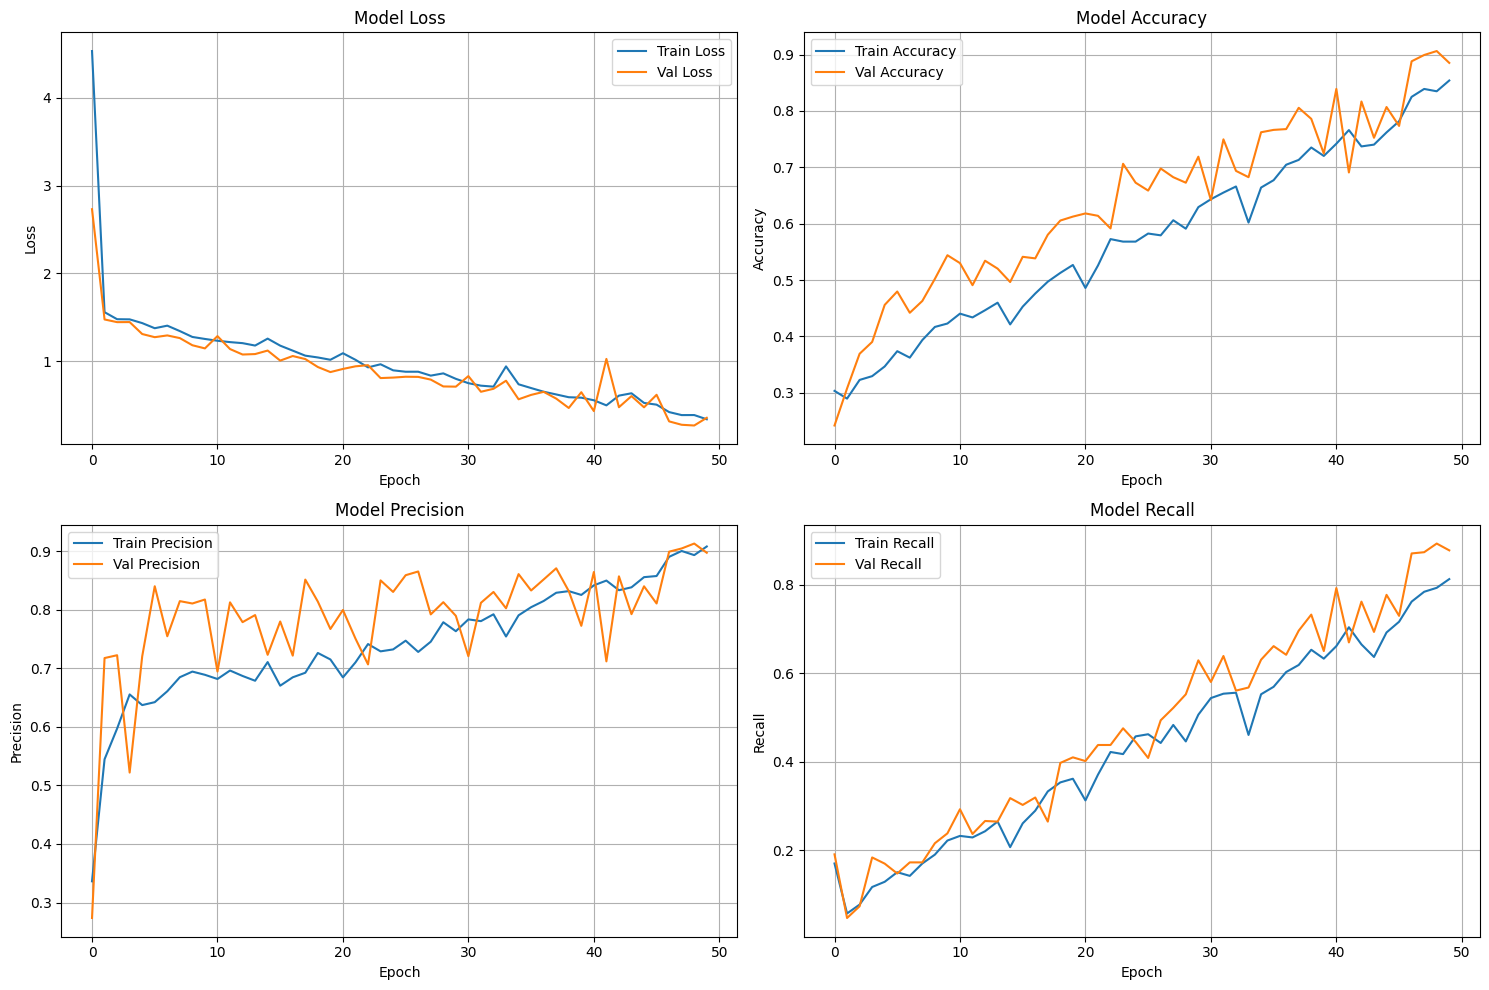

In [8]:
plot_training_history(history)

2. Матрица ошибок (Confusion Matrix)

23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 150ms/step


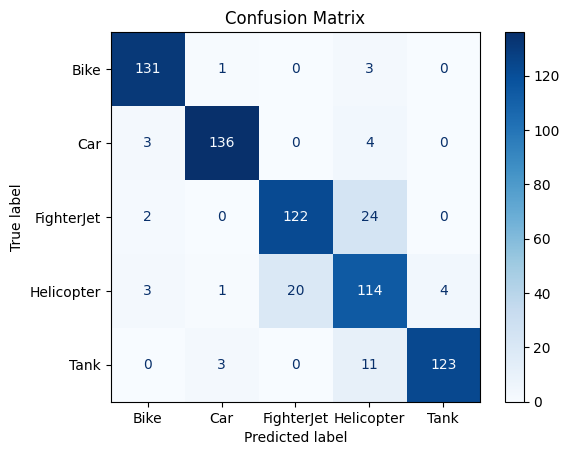

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay 
import numpy as np 
 
# Получение предсказаний на тестовой выборке 
y_pred = model.predict(test_dataset) 
y_pred_classes = np.argmax(y_pred, axis=1) 

# Истинные метки
y_true = np.concatenate([
    np.argmax(labels.numpy(), axis=1)
    for _, labels in test_dataset
])
 
# Построение матрицы ошибок 
cm = confusion_matrix(y_true, y_pred_classes) 
disp = ConfusionMatrixDisplay(confusion_matrix=cm,  
                              display_labels=class_names) 
disp.plot(cmap='Blues', values_format='d') 
plt.title('Confusion Matrix') 
plt.show() 

3. ROC-кривые для каждого класса

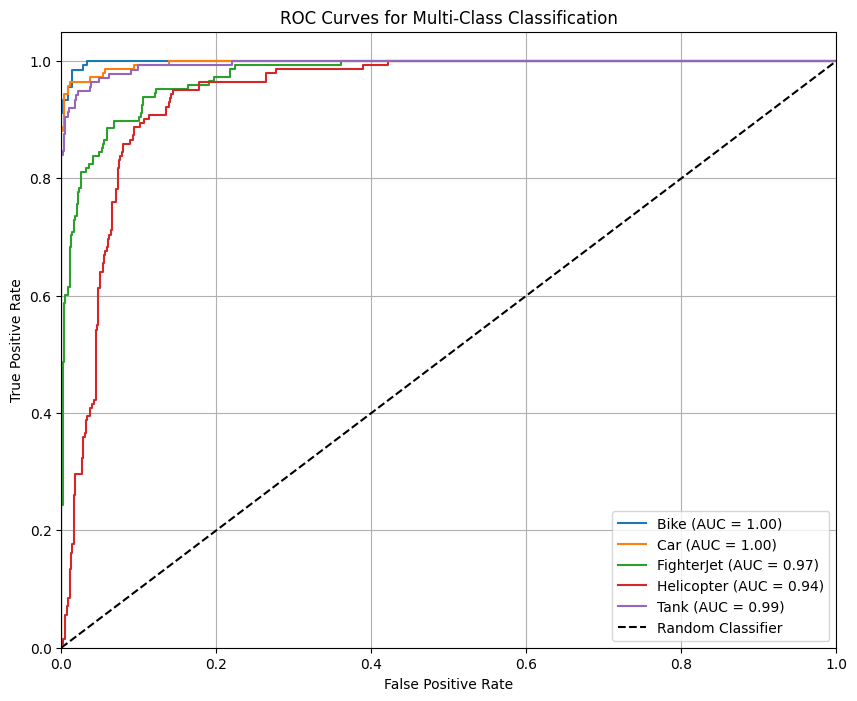

In [10]:
from sklearn.metrics import roc_curve, auc 
from sklearn.preprocessing import label_binarize 
 
# Бинаризация меток для ROC-кривой 
y_test_bin = label_binarize(y_true, classes=range(NUM_CLASSES)) 
 
# Вычисление ROC-кривой для каждого класса 
plt.figure(figsize=(10, 8)) 
for i in range(NUM_CLASSES): 
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred[:, i]) 
    roc_auc = auc(fpr, tpr) 
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})') 
 
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier') 
plt.xlim([0.0, 1.0]) 
plt.ylim([0.0, 1.05]) 
plt.xlabel('False Positive Rate') 
plt.ylabel('True Positive Rate') 
plt.title('ROC Curves for Multi-Class Classification') 
plt.legend(loc="lower right") 
plt.grid(True) 
plt.show() 

4. Таблица метрик по классам

In [11]:
from sklearn.metrics import classification_report 
 
# Вычисление метрик для каждого класса 
report = classification_report(y_true, y_pred_classes,  
                              target_names=class_names, 
                              output_dict=True) 
 
# Создание таблицы 
import pandas as pd 
df_report = pd.DataFrame(report).transpose() 
print(df_report)

              precision    recall  f1-score     support
Bike           0.942446  0.970370  0.956204  135.000000
Car            0.964539  0.951049  0.957746  143.000000
FighterJet     0.859155  0.824324  0.841379  148.000000
Helicopter     0.730769  0.802817  0.765101  142.000000
Tank           0.968504  0.897810  0.931818  137.000000
accuracy       0.887943  0.887943  0.887943    0.887943
macro avg      0.893083  0.889274  0.890450  705.000000
weighted avg   0.891870  0.887943  0.889181  705.000000
